# 02. AI agents

This notebook wires AIMA's `alpha_beta_cutoff_search` to the 6x6 game
from notebook 01, defines the heuristic that the cutoff search uses at
the leaves, and shows a couple of demo games so it's clear the players
actually work. There's also a tiny sanity tournament against random
play at the end. The serious tournament work happens in notebook 03.


In [1]:
import os, sys, random, time
_here = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _here not in sys.path:
    sys.path.insert(0, _here)
import settings, tictactoe66
from games4e import GameState

## The heuristic

`Heuristic` walks every length-`k` window on the board. For each window
it adds `w_two` or `w_three` when the window contains 2 or 3 of our own
markers and none of the opponent's, and subtracts `w_block_two` or
`w_block_three` for the symmetric opponent-only case. Markers in the
central 2x2 get a small `w_center` bonus. Terminal states short-circuit
to plus or minus `w_win`.

Scores are returned from the perspective of the side to move, which is
what `alpha_beta_cutoff_search` expects.


In [2]:
game = tictactoe66.TicTacToe66()
h = tictactoe66.Heuristic(game=game, perspective='X')

# Demo state: X has 3-in-row; O has nothing comparable
demo_board = {(2,2):'X',(2,3):'X',(2,4):'X',(5,5):'O'}
demo_state = GameState(to_move='O', utility=0, board=demo_board,
                       moves=[(x,y) for x in range(1,7) for y in range(1,7) if (x,y) not in demo_board])
game.display(demo_state)
print('heuristic for X:', h(demo_state))
print('heuristic for O:', tictactoe66.Heuristic(game=game, perspective='O')(demo_state))

     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  .  X  X  X  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  O  . |
 6 |  .  .  .  .  .  . |
   +------------------+
heuristic for X: 21.0
heuristic for O: -17.0


## Building an alpha-beta player

`make_alpha_beta_player(depth)` returns a function with the AIMA player
signature `(game, state) -> move`, so we can pass it straight to
`play_one_game` without any glue.


In [3]:
ab_d2 = tictactoe66.make_alpha_beta_player(depth=2, name='AB-d2')
ab_d3 = tictactoe66.make_alpha_beta_player(depth=3, name='AB-d3')

rng = random.Random(settings.RANDOM_SEED)
t0 = time.perf_counter()
res = tictactoe66.play_one_game(game, ab_d2, ab_d2, n_prealloc=2, rng=rng, display=False)
elapsed = time.perf_counter() - t0
print(res, f'elapsed={elapsed:.2f}s')

{'winner': 'X', 'plies': 9, 'n_prealloc': 2} elapsed=0.10s


## A demo game

Two AB(d=2) agents playing against each other from a 1-prealloc start.


In [4]:
rng = random.Random(123)
res = tictactoe66.play_one_game(game, ab_d2, ab_d2, n_prealloc=1, rng=rng, display=True)
print('outcome:', res)

     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  X  .  . |
 2 |  .  .  .  .  .  . |
 3 |  .  .  .  .  .  O |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+

AB-d2 -> (1, 3)
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  X  X  .  . |
 2 |  .  .  .  .  .  . |
 3 |  .  .  .  .  .  O |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+

AB-d2 -> (4, 6)
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  X  X  .  . |
 2 |  .  .  .  .  .  . |
 3 |  .  .  .  .  .  O |
 4 |  .  .  .  .  .  O |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+

AB-d2 -> (1, 2)
     1  2  3  4  5  6
   +------------------+
 1 |  .  X  X  X  .  . |
 2 |  .  .  .  .  .  . |
 3 |  .  .  .  .  .  O |
 4 |  .  .  .  .  .  O |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+

AB-d2 -> (1, 1)
     1  2  3  4  5  6
   +------------------+
 1 |  

## Sanity check vs random play

Ten games against a uniform-random opponent. Even d=2 should win all
ten; if it doesn't, something is wrong with the player or the heuristic.
The real strength evaluation is in notebook 03.


In [5]:
import collections
N = 10
rng = random.Random(0)
results = collections.Counter()
for i in range(N):
    r = tictactoe66.play_one_game(game, ab_d2, tictactoe66.random_legal_player,
                              n_prealloc=2, rng=rng)
    results[r['winner']] += 1
print('AB-d2 (X) vs Random (O) over', N, 'games:', dict(results))

AB-d2 (X) vs Random (O) over 10 games: {'X': 10}


## What does deeper search buy us?

The heuristic alone is myopic: it scores a position from the static counts of
own-vs-opponent markers in each window, with no notion of replies. Alpha-beta
with cutoff is what turns that into actual play. To make the gap concrete I
set up a quiet mid-game position (no immediate threats either way) and ask
the agent for its move at d=1, d=2, and d=3. With no forcing tactics on the
board, every ply of search shifts which cell looks best, which is exactly
the regime where deeper search earns its keep.


In [6]:
# A scattered mid-game position with no immediately forcing tactics.
# Positions like this are where deeper search matters most: the heuristic
# is roughly indifferent across many moves, so which one looks best ends
# up depending on what the search sees a few plies out.
demo_board = {
    (1, 1): 'X', (1, 4): 'X', (6, 3): 'X',
    (3, 2): 'O', (2, 6): 'O', (5, 4): 'O',
}
moves = [(r, c) for r in range(1, game.h + 1)
                for c in range(1, game.v + 1)
                if (r, c) not in demo_board]
demo_state = GameState(to_move='X', utility=0, board=demo_board, moves=moves)
game.display(demo_state)

# Run alpha-beta at three depths, record the chosen move and the heuristic
# value of the resulting position from O's point of view.
chosen, evals = {}, {}
for d in (1, 2, 3):
    player = tictactoe66.make_alpha_beta_player(depth=d, name=f'AB-d{d}')
    move   = player(game, demo_state)
    next_state = game.result(demo_state, move)
    h_x    = tictactoe66.Heuristic(game=game, perspective='X')
    chosen[d] = move
    evals[d]  = h_x(next_state)
    print(f"  d={d}: chose {move}  (resulting heuristic for X: {evals[d]:+.1f})")


     1  2  3  4  5  6
   +------------------+
 1 |  X  .  .  X  .  . |
 2 |  .  .  .  .  .  O |
 3 |  .  O  .  .  .  . |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  O  .  . |
 6 |  .  .  X  .  .  . |
   +------------------+
  d=1: chose (4, 3)  (resulting heuristic for X: +2.5)
  d=2: chose (6, 5)  (resulting heuristic for X: +2.0)
  d=3: chose (1, 2)  (resulting heuristic for X: +9.0)


The cell above prints the chosen move per depth and the heuristic value
of the position that move produces (from X's perspective, so higher is
better for X). The chart pairs that with a board overlay so it's easy to
see what each depth chose.


saved C:\Git\AI801Project\cache\figures\move_quality_vs_depth.png


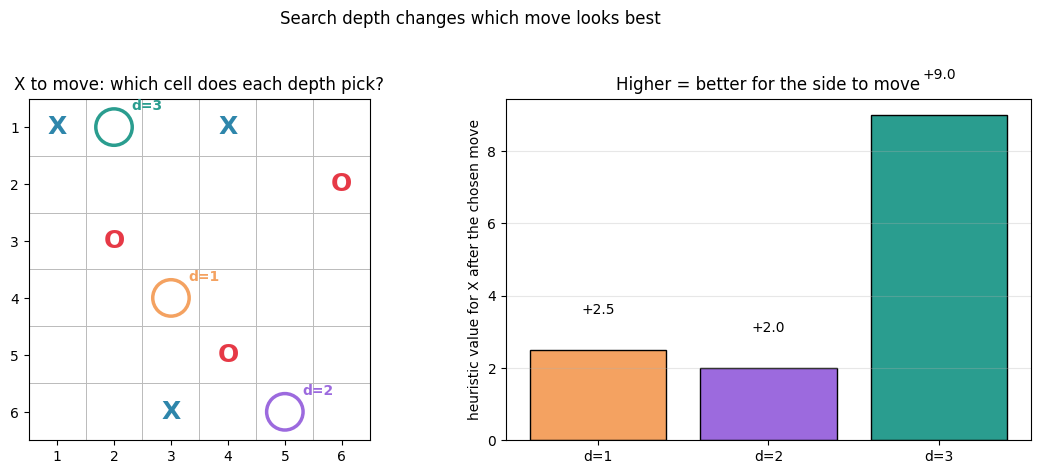

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6),
                         gridspec_kw={'width_ratios': [1.1, 1]})

# Left: the position with each depth's chosen move marked.
ax = axes[0]
N = game.h
for r in range(1, N + 1):
    for c in range(1, N + 1):
        ax.add_patch(mpatches.Rectangle((c - 0.5, N - r + 0.5), 1, 1,
                     fill=False, edgecolor='#bbbbbb', linewidth=0.6))
        v = demo_board.get((r, c))
        if v == 'X':
            ax.text(c, N - r + 1, 'X', ha='center', va='center',
                    fontsize=18, color='#2E86AB', weight='bold')
        elif v == 'O':
            ax.text(c, N - r + 1, 'O', ha='center', va='center',
                    fontsize=18, color='#E63946', weight='bold')

depth_colors = {1: '#F4A261', 2: '#9C6ADE', 3: '#2A9D8F'}
for d, mv in chosen.items():
    r, c = mv
    ax.add_patch(mpatches.Circle((c, N - r + 1), 0.32, fill=False,
                                  edgecolor=depth_colors[d], linewidth=2.5))
    ax.text(c + 0.30, N - r + 1.30, f'd={d}',
            color=depth_colors[d], fontsize=10, weight='bold')

ax.set_xlim(0.5, N + 0.5); ax.set_ylim(0.5, N + 0.5)
ax.set_xticks(range(1, N + 1)); ax.set_yticks(range(1, N + 1))
ax.set_yticklabels([str(N - i + 1) for i in range(1, N + 1)])
ax.set_aspect('equal')
ax.set_title("X to move: which cell does each depth pick?")

# Right: heuristic value of the position resulting from each chosen move.
ax2 = axes[1]
ds   = sorted(evals)
vals = [evals[d] for d in ds]
bars = ax2.bar([f'd={d}' for d in ds], vals,
               color=[depth_colors[d] for d in ds],
               edgecolor='black')
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width()/2,
             v + (1 if v >= 0 else -3),
             f'{v:+.1f}', ha='center', fontsize=10)
ax2.axhline(0, color='black', lw=0.7)
ax2.set_ylabel("heuristic value for X after the chosen move")
ax2.set_title("Higher = better for the side to move")
ax2.grid(axis='y', alpha=0.3)

fig.suptitle("Search depth changes which move looks best", y=1.02, fontsize=12)
fig.tight_layout()
out = settings.FIGURES_DIR / 'move_quality_vs_depth.png'
fig.savefig(out, dpi=120, bbox_inches='tight')
print('saved', out)
plt.show()


If d=1 picks a move and d=3 picks a different one, that's the search
catching a forcing reply the heuristic missed. If all three depths agree,
the position is decided enough that the heuristic alone is sufficient,
which itself is a useful data point.


## What does the heuristic see?

Calling `Heuristic` on every legal next state turns the evaluation
function into a per-cell score map. Greener cells are higher-value
moves from the side-to-move's perspective; existing markers are
overlaid for context. This is the signal alpha-beta is maximizing over
at the leaves of its search tree.


saved C:\Git\AI801Project\cache\figures\heuristic_heatmaps.png


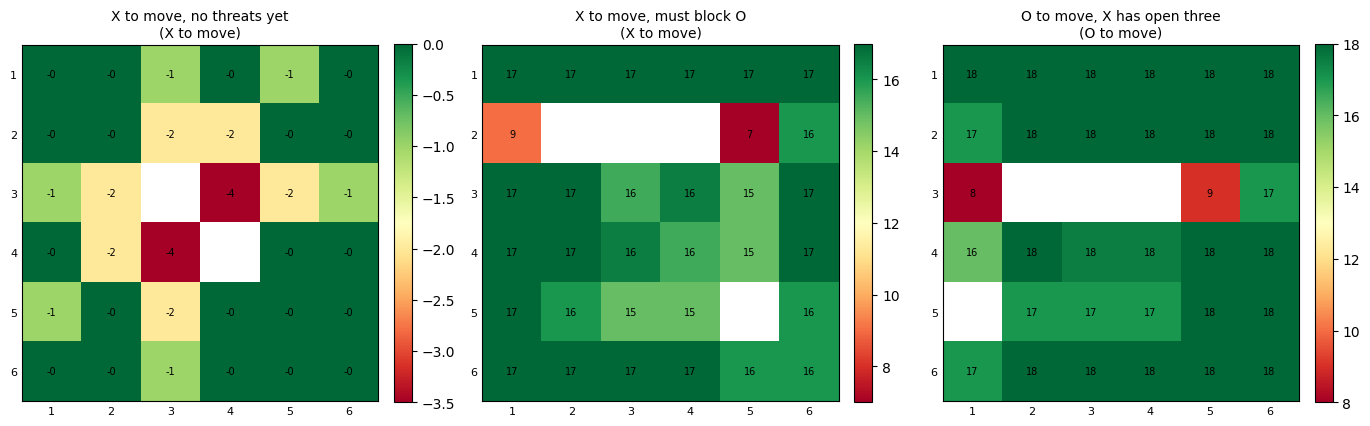

In [8]:
import matplotlib.pyplot as plt
import viz

scenarios = [
    ('X to move, no threats yet', {(3, 3): 'X', (4, 4): 'O'}, 'X'),
    ('X to move, must block O',   {(2, 2): 'O', (2, 3): 'O', (2, 4): 'O', (5, 5): 'X'}, 'X'),
    ('O to move, X has open three', {(3, 2): 'X', (3, 3): 'X', (3, 4): 'X', (5, 1): 'O'}, 'O'),
]

fig, axes = plt.subplots(1, len(scenarios), figsize=(4.6 * len(scenarios), 4.4))
for ax, (title, board, to_move) in zip(axes, scenarios):
    moves = [(r, c) for r in range(1, game.h + 1)
                    for c in range(1, game.v + 1)
                    if (r, c) not in board]
    state = GameState(to_move=to_move, utility=0, board=board, moves=moves)
    heur = tictactoe66.Heuristic(game=game, perspective=to_move)
    im = viz.draw_heuristic_heatmap(ax, game, state, heur)
    ax.set_title(f'{title}\n({to_move} to move)', fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
out = settings.FIGURES_DIR / 'heuristic_heatmaps.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


## Sanity tournament as a chart

Same 10-game result, plotted as a bar chart for easy reuse in slides.


saved C:\Git\AI801Project\cache\figures\ab_vs_random.png


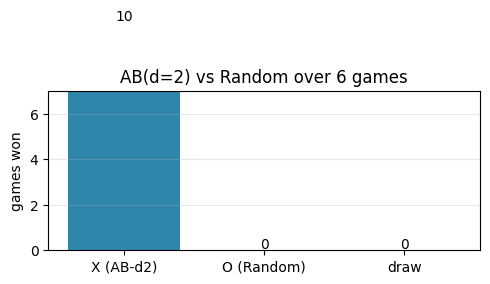

In [9]:
import matplotlib.pyplot as plt

labels = ['X (AB-d2)', 'O (Random)', 'draw']
counts = [results.get('X', 0), results.get('O', 0), results.get('draw', 0)]
colors = ['#2E86AB', '#E63946', '#888888']

fig, ax = plt.subplots(figsize=(5, 3.4))
bars = ax.bar(labels, counts, color=colors)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
            str(c), ha='center', fontsize=10)
ax.set_ylabel('games won')
ax.set_ylim(0, N + 1)
ax.set_title(f'AB(d=2) vs Random over {N} games')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out = settings.FIGURES_DIR / 'ab_vs_random.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


That's the agent stack: heuristic, alpha-beta, and a player factory
that wraps both. Notebook 03 sweeps depth and weights to find a
configuration that beats the defaults (spoiler: it doesn't).
